# ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar diez clases que incluyen fundamentalmente animales y vehículos.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en 60000 imágenes a color de 10 clases de animales y vehículos. El dataset en cuestión se denomina [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) y es más complejo que el dataset MNIST que hemos utilizado en la actividad 1. Aunque tiene las mismas clases (10), los animales y vehículos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros animales/ vehículos en pantalla (si bien el elemento a clasificar siempre aparece en la posición predominante).

## Carga de los datos

In [1]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import pandas as pd
import keras.datasets.cifar10 as cifar10

from tensorflow import keras
from keras.utils import to_categorical

In [2]:
# Primero, definimos los datos de entrenamiento, validación y prueba
(X, Y), (x_test, y_test) = cifar10.load_data()
(x_train, x_valid) = (X[:40000], X[40000:])
(y_train, y_valid) = (Y[:40000], Y[40000:])

/Users/alejandromorales/Library/CloudStorage/OneDrive-Personal/Documentos/Máster en Inteligencia Artificial/2º SEMESTRE/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
# Normalizamos como de costumbre
x_train = x_train / 255.
x_valid = x_valid / 255.
x_test = x_test / 255.

In [4]:
# Esta variable contiene un mapeo de número de clase a elemento (animal o vehículo).
# La incluimos para ayudarte con la identificación de clases. De ti depende
# si quieres utilizar esta variable o no
MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

In [5]:
# Función auxiliar para convertir las etiquetas a codificación one-hot
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

# Convertimos las etiquetas de entrenamiento, validación y prueba
num_classes = 10
y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot = convert_to_one_hot(y_test, num_classes)

# Verificamos las conversiones
print(y_train_one_hot.shape)
print(y_valid_one_hot.shape)
print(y_test_one_hot.shape)

(40000, 10)
(10000, 10)
(10000, 10)


## Ejercicio

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer una imagen de las incluidas en CIFAR-10 con la mayor accuracy posible. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Te recomendamos mantener los conjuntos de entrenamiento, test y prueba que se crean en el Notebook. No obstante, si crees que modificando tales conjuntos puedes lograr mejores resultados (o que puedes lograr los mismos resultados con menos datos, lo cual es también un logro), eres libre de hacerlo.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.

## 1. Análisis exploratorio de los datos

Antes de construir ningún modelo, conviene entender bien con qué estamos trabajando. CIFAR-10 es un dataset bastante más complejo que MNIST: las imágenes son a color (3 canales RGB), de resolución 32×32 y representan objetos del mundo real con fondos variados, lo cual lo convierte en un reto interesante para clasificación.

In [6]:
print(f"Conjunto de entrenamiento: {x_train.shape[0]} imágenes")
print(f"Conjunto de validación:    {x_valid.shape[0]} imágenes")
print(f"Conjunto de test:          {x_test.shape[0]} imágenes")
print(f"\nDimensiones de cada imagen: {x_train.shape[1:]} (alto x ancho x canales RGB)")
print(f"Rango de valores (tras normalizar): [{x_train.min():.1f}, {x_train.max():.1f}]")
print(f"Número de clases: {num_classes}")

Conjunto de entrenamiento: 40000 imágenes
Conjunto de validación:    10000 imágenes
Conjunto de test:          10000 imágenes

Dimensiones de cada imagen: (32, 32, 3) (alto x ancho x canales RGB)
Rango de valores (tras normalizar): [0.0, 1.0]
Número de clases: 10


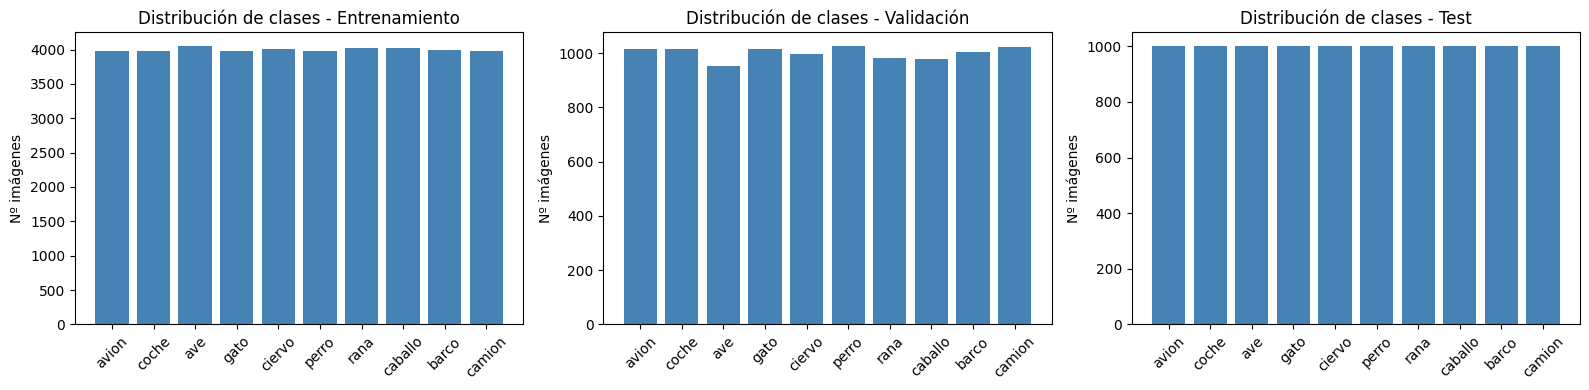

In [7]:
# Distribución de clases en cada conjunto
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, labels, titulo in zip(axes,
                               [y_train, y_valid, y_test],
                               ['Entrenamiento', 'Validación', 'Test']):
    clases, conteos = np.unique(labels, return_counts=True)
    nombres = [MAP_ELEMENTS[c] for c in clases]
    ax.bar(nombres, conteos, color='steelblue')
    ax.set_title(f'Distribución de clases - {titulo}')
    ax.set_ylabel('Nº imágenes')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

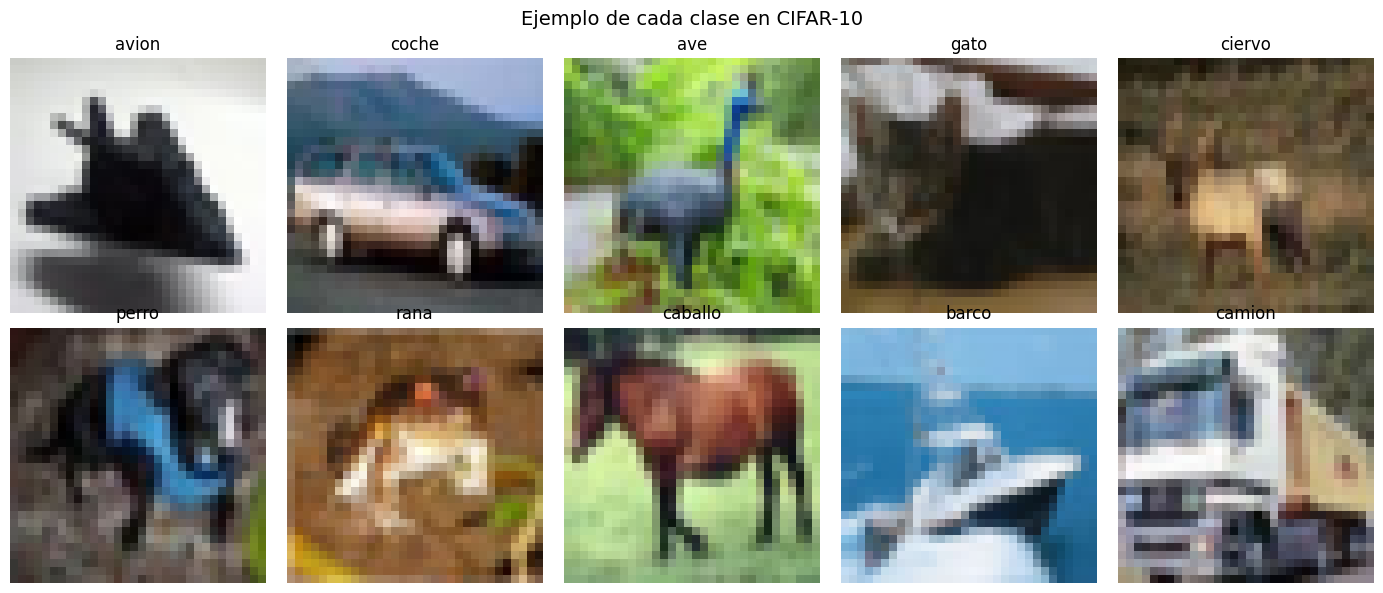

In [8]:
# Visualizamos algunas imágenes de ejemplo por clase
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for clase in range(10):
    ax = axes[clase // 5, clase % 5]
    idx = np.where(y_train.flatten() == clase)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(MAP_ELEMENTS[clase], fontsize=12)
    ax.axis('off')

plt.suptitle('Ejemplo de cada clase en CIFAR-10', fontsize=14)
plt.tight_layout()
plt.show()

Las clases están perfectamente balanceadas, con aproximadamente 4000 imágenes por clase en training, 1000 en validación y 1000 en test. No necesitamos aplicar ninguna técnica de balanceo. Las imágenes son de 32×32 píxeles con 3 canales RGB, lo que da un total de 3072 valores por imagen. A diferencia de MNIST, aquí las imágenes tienen fondos complejos, variaciones de pose y en general mucha más variabilidad intraclase, lo que hace el problema considerablemente más difícil.

## 2. Modelo baseline: Fully Connected

Como punto de partida, vamos a entrenar una red densa (Fully Connected) similar a las que usamos en la actividad 1 con MNIST. La idea es tener una referencia clara de rendimiento para después ver cuánto mejora una CNN. Para ello, aplanamos las imágenes de 32×32×3 a vectores de 3072 elementos y los pasamos por capas Dense.

In [9]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping

# Modelo Fully Connected como baseline
fc_model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

fc_model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

fc_model.summary()

/Users/alejandromorales/Library/CloudStorage/OneDrive-Personal/Documentos/Máster en Inteligencia Artificial/2º SEMESTRE/Redes Neuronales y Aprendizaje Profundo/.venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

fc_history = fc_model.fit(
    x_train, y_train_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(x_valid, y_valid_one_hot),
    callbacks=[early_stop]
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2378 - loss: 2.0583 - val_accuracy: 0.3169 - val_loss: 1.8892
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2909 - loss: 1.9234 - val_accuracy: 0.3623 - val_loss: 1.8041
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3043 - loss: 1.8849 - val_accuracy: 0.3593 - val_loss: 1.8268
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3143 - loss: 1.8598 - val_accuracy: 0.3658 - val_loss: 1.7863
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3239 - loss: 1.8349 - val_accuracy: 0.3727 - val_loss: 1.7827
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3339 - loss: 1.8240 - val_accuracy: 0.3824 - val_loss: 1.7590
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3388 - loss: 1.8032 - val_accuracy: 0.3846 - val_loss: 1.7471
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3440 - loss: 1.7987 - val_accuracy: 0.

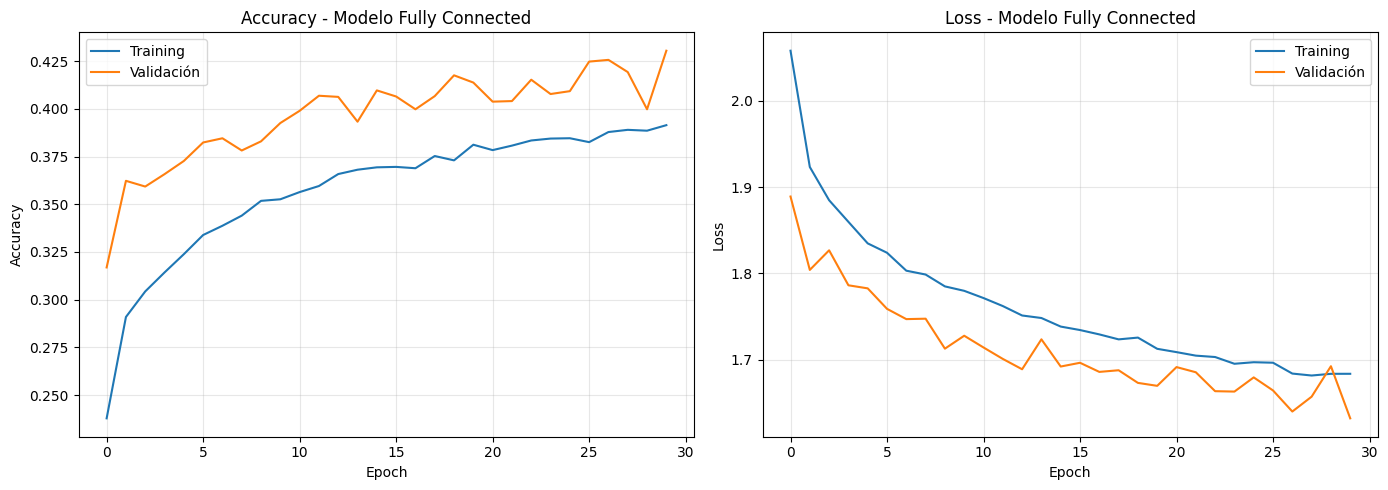


Resultados en TEST - Modelo FC: accuracy = 0.4306, loss = 1.6167


In [11]:
# Curvas de entrenamiento del modelo FC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(fc_history.history['accuracy'], label='Training')
ax1.plot(fc_history.history['val_accuracy'], label='Validación')
ax1.set_title('Accuracy - Modelo Fully Connected')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(fc_history.history['loss'], label='Training')
ax2.plot(fc_history.history['val_loss'], label='Validación')
ax2.set_title('Loss - Modelo Fully Connected')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluación en test
fc_test_loss, fc_test_acc = fc_model.evaluate(x_test, y_test_one_hot, verbose=0)
print(f"\nResultados en TEST - Modelo FC: accuracy = {fc_test_acc:.4f}, loss = {fc_test_loss:.4f}")

El modelo Fully Connected obtiene un **43.06% de accuracy en test**, que es bastante pobre. Aunque tiene 1.7M de parámetros, apenas supera al azar (que sería un 10% con 10 clases). El problema es que al aplanar la imagen perdemos toda la estructura espacial: la red no sabe que los píxeles vecinos están relacionados, ni puede detectar bordes, texturas o formas. Precisamente para eso existen las CNNs, que explotan la localidad espacial de las imágenes mediante filtros convolucionales. Veamos cuánto mejora.

## 3. Primera CNN: arquitectura simple

Empezamos con una CNN básica para establecer un segundo punto de referencia. La arquitectura consta de dos bloques convolucionales (Conv2D + MaxPooling) seguidos de una cabeza densa. Es una estructura estándar que nos permitirá ver de forma inmediata el beneficio de usar convoluciones frente a la red densa anterior.

In [12]:
from keras.layers import Conv2D, MaxPooling2D, Input

# CNN simple: 2 bloques convolucionales
cnn_simple = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

cnn_simple.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

cnn_simple.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

cnn_simple_history = cnn_simple.fit(
    x_train, y_train_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(x_valid, y_valid_one_hot),
    callbacks=[early_stop]
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4185 - loss: 1.5996 - val_accuracy: 0.5055 - val_loss: 1.4127
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5630 - loss: 1.2313 - val_accuracy: 0.6328 - val_loss: 1.0681
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6169 - loss: 1.0862 - val_accuracy: 0.6508 - val_loss: 1.0017
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6532 - loss: 0.9795 - val_accuracy: 0.6770 - val_loss: 0.9152
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6811 - loss: 0.9058 - val_accuracy: 0.6787 - val_loss: 0.9136
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7030 - loss: 0.8402 - val_accuracy: 0.6984 - val_loss: 0.8746
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7240 - loss: 0.7826 - val_accuracy: 0.7011 - val_loss: 0.8713
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7377 - loss: 0.7366 - val_accu

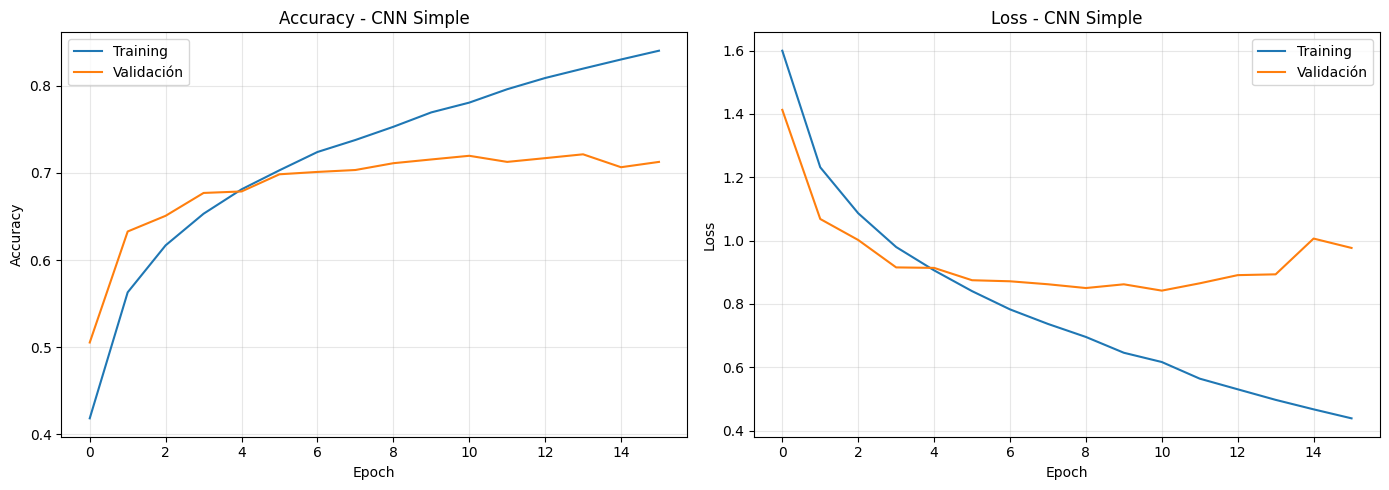


Resultados en TEST - CNN Simple: accuracy = 0.7169, loss = 0.8467
Mejora respecto al modelo FC: +28.63 puntos porcentuales


In [14]:
# Curvas de entrenamiento CNN simple
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cnn_simple_history.history['accuracy'], label='Training')
ax1.plot(cnn_simple_history.history['val_accuracy'], label='Validación')
ax1.set_title('Accuracy - CNN Simple')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(cnn_simple_history.history['loss'], label='Training')
ax2.plot(cnn_simple_history.history['val_loss'], label='Validación')
ax2.set_title('Loss - CNN Simple')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

cnn_simple_loss, cnn_simple_acc = cnn_simple.evaluate(x_test, y_test_one_hot, verbose=0)
print(f"\nResultados en TEST - CNN Simple: accuracy = {cnn_simple_acc:.4f}, loss = {cnn_simple_loss:.4f}")
print(f"Mejora respecto al modelo FC: +{(cnn_simple_acc - fc_test_acc)*100:.2f} puntos porcentuales")

La CNN simple ya marca una diferencia enorme frente al modelo FC: pasamos de un 43.06% a un **71.69% en test**, una mejora de casi 30 puntos porcentuales. Esto confirma lo que comentábamos antes: las convoluciones son capaces de capturar patrones espaciales (bordes, texturas, formas) que una red densa simplemente ignora. Aun así, se observa overfitting a partir de la epoch 11 aproximadamente, con el training subiendo hasta ~80% mientras la validación se estanca en torno al 70%. Vamos a intentar reducir ese gap y mejorar el rendimiento con una CNN más profunda y técnicas de regularización.

## 4. CNN profunda con Batch Normalization y regularización

En esta sección aumentamos la profundidad de la red con 3 bloques convolucionales, cada uno con dos capas Conv2D seguidas de BatchNormalization, MaxPooling y Dropout. La Batch Normalization normaliza las activaciones entre capas, lo que estabiliza y acelera el entrenamiento, mientras que el Dropout ayuda a combatir el overfitting que veíamos en la CNN simple. Además, incrementamos progresivamente el número de filtros (32 → 64 → 128) para que las capas más profundas puedan capturar patrones cada vez más abstractos.

In [15]:
# CNN profunda con BatchNormalization + Dropout
cnn_deep = Sequential([
    Input(shape=(32, 32, 3)),

    # Bloque 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Bloque 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Bloque 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Cabeza clasificadora
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn_deep.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

cnn_deep.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [16]:
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

cnn_deep_history = cnn_deep.fit(
    x_train, y_train_one_hot,
    epochs=50,
    batch_size=64,
    validation_data=(x_valid, y_valid_one_hot),
    callbacks=[early_stop]
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 56ms/step - accuracy: 0.4524 - loss: 1.6243 - val_accuracy: 0.5860 - val_loss: 1.1487
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.6245 - loss: 1.0656 - val_accuracy: 0.5824 - val_loss: 1.2442
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.6863 - loss: 0.8937 - val_accuracy: 0.7175 - val_loss: 0.8134
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.7217 - loss: 0.7941 - val_accuracy: 0.7474 - val_loss: 0.7368
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.7461 - loss: 0.7210 - val_accuracy: 0.6873 - val_loss: 0.9215
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.7704 - loss: 0.6607 - val_accuracy: 0.7742 - val_loss: 0.6594
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.7871 - loss: 0.6157 - val_accuracy: 0.7912 - val_loss: 0.6112
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.8033 - loss: 0.5647 - 

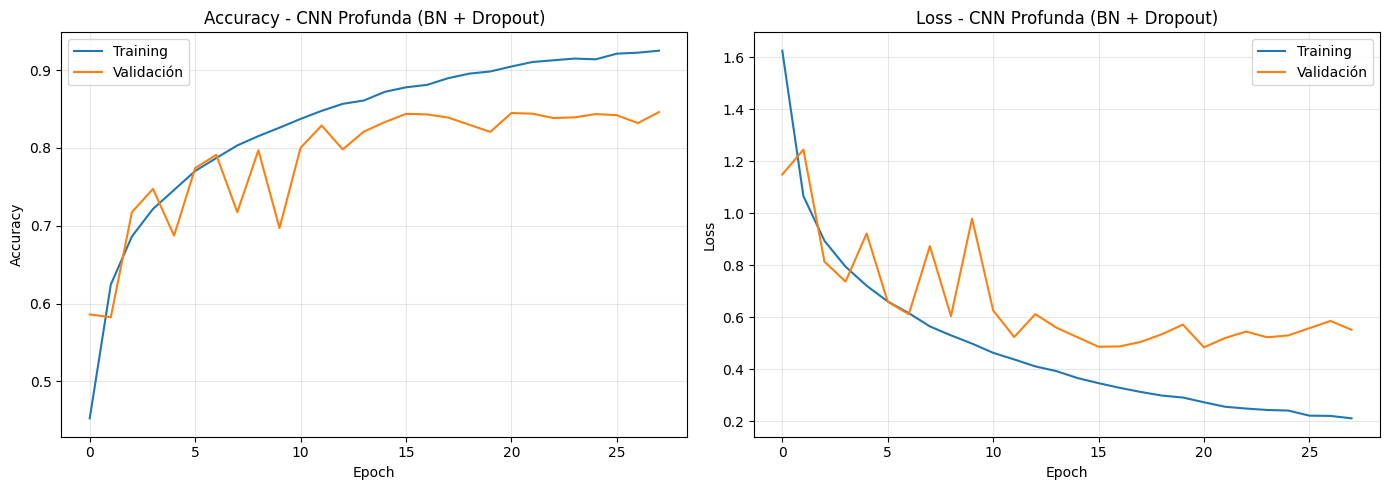


Resultados en TEST - CNN Profunda: accuracy = 0.8410, loss = 0.5099
Mejora respecto a CNN Simple: +12.41 puntos porcentuales


In [17]:
# Curvas de entrenamiento CNN profunda
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cnn_deep_history.history['accuracy'], label='Training')
ax1.plot(cnn_deep_history.history['val_accuracy'], label='Validación')
ax1.set_title('Accuracy - CNN Profunda (BN + Dropout)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(cnn_deep_history.history['loss'], label='Training')
ax2.plot(cnn_deep_history.history['val_loss'], label='Validación')
ax2.set_title('Loss - CNN Profunda (BN + Dropout)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

cnn_deep_loss, cnn_deep_acc = cnn_deep.evaluate(x_test, y_test_one_hot, verbose=0)
print(f"\nResultados en TEST - CNN Profunda: accuracy = {cnn_deep_acc:.4f}, loss = {cnn_deep_loss:.4f}")
print(f"Mejora respecto a CNN Simple: +{(cnn_deep_acc - cnn_simple_acc)*100:.2f} puntos porcentuales")

La mejora es notable: pasamos de 71.69% a **84.10% en test**. La combinación de mayor profundidad, Batch Normalization y Dropout ha sido clave. Sin embargo, sigue existiendo un gap importante entre training (~92%) y validación (~84%), lo que indica que el modelo todavía está memorizando parte de los datos de entrenamiento. Para atacar este problema, en la siguiente sección vamos a aplicar data augmentation, que consiste en generar variaciones artificiales de las imágenes (rotaciones, flips, desplazamientos) para que la red vea más diversidad durante el entrenamiento sin necesidad de más datos reales.

## 5. Modelo final: CNN profunda con Data Augmentation

El data augmentation es una técnica de regularización muy potente en visión por computador. En cada epoch, las imágenes de entrenamiento se transforman aleatoriamente (rotación, desplazamiento horizontal/vertical, flip horizontal), de forma que la red nunca ve exactamente la misma imagen dos veces. Esto fuerza al modelo a aprender representaciones más robustas y generalizables. Usamos la misma arquitectura de la sección anterior pero entrenada con augmentation, y además añadimos un learning rate scheduler que reduce la tasa de aprendizaje cuando la validación deja de mejorar.

In [19]:
from keras import layers as L
from keras.callbacks import ReduceLROnPlateau

# Data augmentation como capas del modelo (Keras 3)
data_augmentation = Sequential([
    L.RandomFlip("horizontal"),
    L.RandomRotation(0.05),
    L.RandomTranslation(0.1, 0.1),
])

# CNN con augmentation integrada
cnn_aug = Sequential([
    Input(shape=(32, 32, 3)),
    data_augmentation,

    # Bloque 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Bloque 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Bloque 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Cabeza clasificadora
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn_aug.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print(f"Parámetros totales: {cnn_aug.count_params():,}")

Parámetros totales: 816,938


In [20]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

cnn_aug_history = cnn_aug.fit(
    x_train, y_train_one_hot,
    epochs=80,
    batch_size=64,
    validation_data=(x_valid, y_valid_one_hot),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 58ms/step - accuracy: 0.3818 - loss: 1.8312 - val_accuracy: 0.5319 - val_loss: 1.3079 - learning_rate: 0.0010
Epoch 2/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.5215 - loss: 1.3346 - val_accuracy: 0.5647 - val_loss: 1.2420 - learning_rate: 0.0010
Epoch 3/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.5878 - loss: 1.1577 - val_accuracy: 0.6656 - val_loss: 0.9525 - learning_rate: 0.0010
Epoch 4/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.6350 - loss: 1.0425 - val_accuracy: 0.6691 - val_loss: 0.9451 - learning_rate: 0.0010
Epoch 5/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.6640 - loss: 0.9616 - val_accuracy: 0.6064 - val_loss: 1.3285 - learning_rate: 0.0010
Epoch 6/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.6841 - loss: 0.9092 - val_accuracy: 0.6876 - val_loss: 0.9103 - learning_rate: 0.0010
Epoch 7/80
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.7060 - l

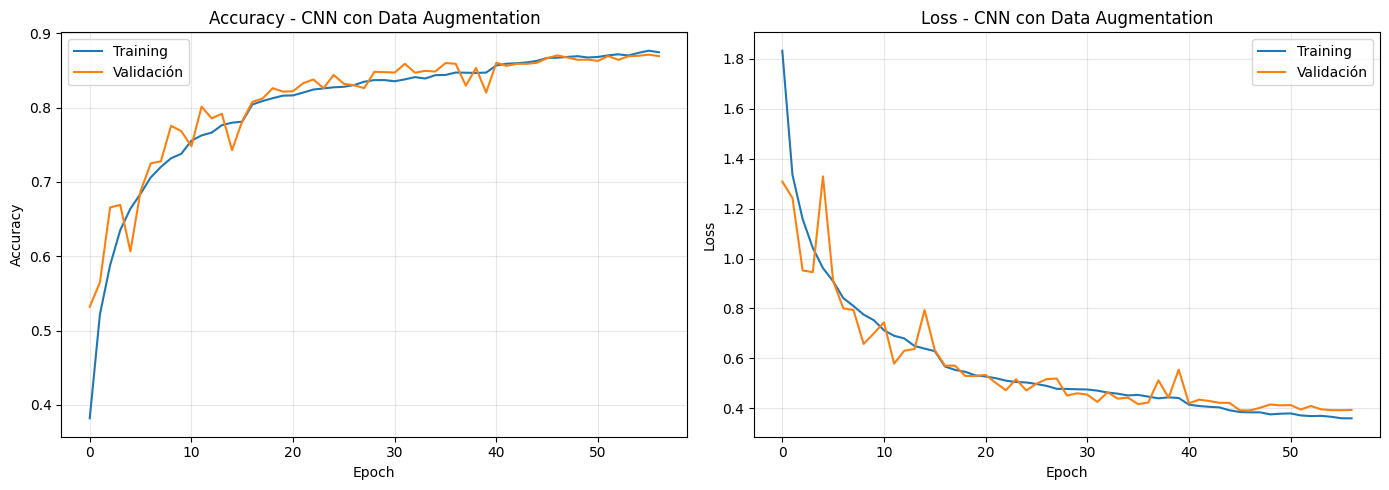


Resultados en TEST - CNN con Data Augmentation: accuracy = 0.8666, loss = 0.4056
Mejora respecto a CNN Profunda (sin augmentation): +2.56 puntos porcentuales


In [21]:
# Curvas de entrenamiento del modelo final con data augmentation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cnn_aug_history.history['accuracy'], label='Training')
ax1.plot(cnn_aug_history.history['val_accuracy'], label='Validación')
ax1.set_title('Accuracy - CNN con Data Augmentation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(cnn_aug_history.history['loss'], label='Training')
ax2.plot(cnn_aug_history.history['val_loss'], label='Validación')
ax2.set_title('Loss - CNN con Data Augmentation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

cnn_aug_loss, cnn_aug_acc = cnn_aug.evaluate(x_test, y_test_one_hot, verbose=0)
print(f"\nResultados en TEST - CNN con Data Augmentation: accuracy = {cnn_aug_acc:.4f}, loss = {cnn_aug_loss:.4f}")
print(f"Mejora respecto a CNN Profunda (sin augmentation): +{(cnn_aug_acc - cnn_deep_acc)*100:.2f} puntos porcentuales")

El data augmentation consigue subir el rendimiento a **86.66% en test**, y lo más relevante es que el gap entre training y validación se ha reducido drásticamente. Mientras que la CNN profunda sin augmentation tenía un gap de ~8 puntos (92% vs 84%), ahora training y validación están prácticamente igualados (~87%), lo que indica una generalización mucho más sana. El ReduceLROnPlateau también ha ayudado, reduciendo el learning rate progresivamente para afinar el entrenamiento en las últimas epochs.

## 6. Análisis de resultados del mejor modelo

Vamos a analizar en detalle el rendimiento del mejor modelo (CNN con data augmentation). Empezamos con las métricas de precision y recall por clase, la matriz de confusión y un análisis visual de los errores para entender qué tipo de imágenes le resultan más difíciles.

In [24]:
!pip install scikit-learn seaborn -q


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predicciones del mejor modelo sobre test
y_pred_probs = cnn_aug.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Métricas por clase
nombres_clases = [MAP_ELEMENTS[i] for i in range(10)]
print(classification_report(y_true, y_pred, target_names=nombres_clases, digits=4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
              precision    recall  f1-score   support

       avion     0.8783    0.8730    0.8756      1000
       coche     0.9369    0.9510    0.9439      1000
         ave     0.8524    0.8030    0.8270      1000
        gato     0.8264    0.6570    0.7320      1000
      ciervo     0.8495    0.8580    0.8537      1000
       perro     0.8349    0.7790    0.8060      1000
        rana     0.7882    0.9640    0.8673      1000
     caballo     0.8822    0.9140    0.8978      1000
       barco     0.9454    0.9180    0.9315      1000
      camion     0.8779    0.9490    0.9121      1000

    accuracy                         0.8666     10000
   macro avg     0.8672    0.8666    0.8647     10000
weighted avg     0.8672    0.8666    0.8647     10000



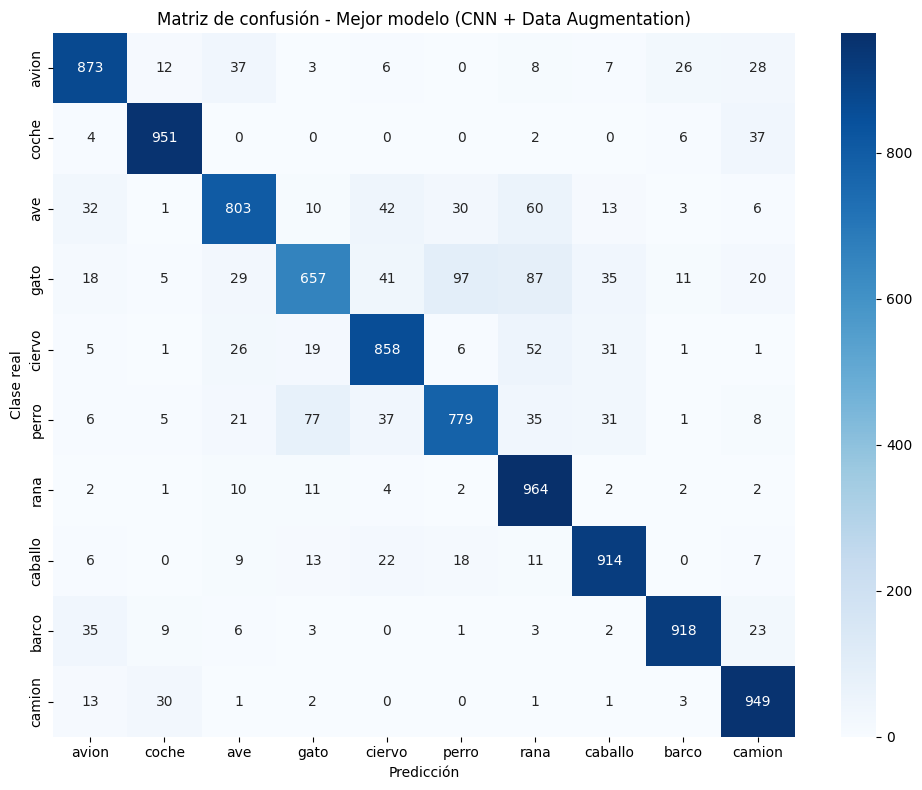

In [26]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases, ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Clase real')
ax.set_title('Matriz de confusión - Mejor modelo (CNN + Data Augmentation)')
plt.tight_layout()
plt.show()

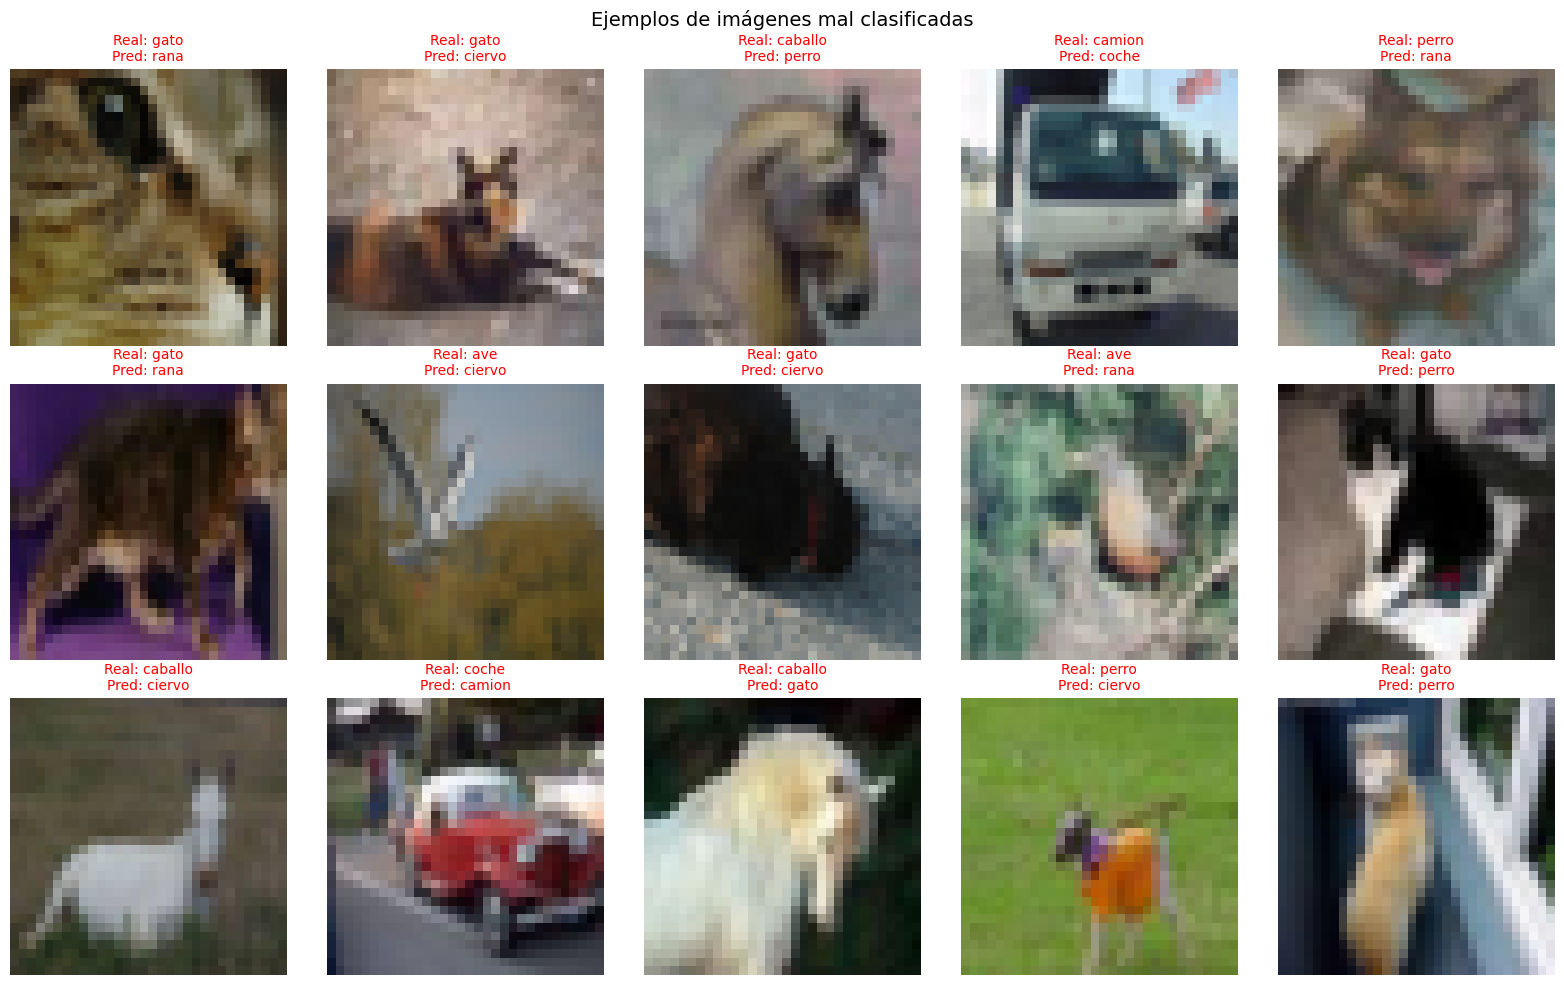


Total de errores en test: 1334 de 10000 (13.34%)


In [27]:
# Análisis visual de errores: mostramos imágenes mal clasificadas
errores_idx = np.where(y_pred != y_true)[0]
np.random.seed(42)
muestra_errores = np.random.choice(errores_idx, size=min(15, len(errores_idx)), replace=False)

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for i, idx in enumerate(muestra_errores):
    ax = axes[i // 5, i % 5]
    ax.imshow(x_test[idx])
    ax.set_title(f"Real: {MAP_ELEMENTS[y_true[idx]]}\nPred: {MAP_ELEMENTS[y_pred[idx]]}", 
                 fontsize=10, color='red')
    ax.axis('off')

plt.suptitle('Ejemplos de imágenes mal clasificadas', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nTotal de errores en test: {len(errores_idx)} de {len(y_true)} ({len(errores_idx)/len(y_true)*100:.2f}%)")

Las métricas por clase revelan diferencias interesantes. Las clases que mejor se clasifican son **coche** (F1=0.94), **barco** (F1=0.93) y **camión** (F1=0.91), que tienen formas geométricas más definidas y fácilmente distinguibles. En el extremo opuesto, **gato** (F1=0.73) y **perro** (F1=0.81) son las clases más problemáticas, lo cual tiene todo el sentido: son animales con formas similares, pelaje variado y que a veces aparecen en poses parecidas. De hecho, la matriz de confusión muestra que muchos gatos se confunden con perros y viceversa.

También es llamativo el caso de la **rana**, que tiene un recall altísimo (0.96) pero una precision más baja (0.79). Esto significa que el modelo es muy bueno detectando ranas cuando las ve, pero a veces clasifica erróneamente otras clases como rana (probablemente por el fondo verde o la textura).

En cuanto al análisis visual de errores, muchas de las imágenes mal clasificadas son realmente ambiguas incluso para un humano a 32×32 píxeles: imágenes oscuras, objetos parcialmente ocultos o fondos que se confunden con el objeto.

## 7. Comparativa final de modelos

Resumimos los resultados de todos los modelos entrenados a lo largo de esta actividad:

| Modelo | Accuracy Test | Parámetros | Observaciones |
|--------|:------------:|:----------:|---------------|
| Fully Connected (baseline) | 43.06% | 1.7M | Pierde toda la información espacial |
| CNN Simple (2 bloques) | 71.69% | 545K | Gran salto, pero overfitting severo |
| CNN Profunda (BN + Dropout) | 84.10% | 816K | BatchNorm y Dropout reducen el gap |
| CNN Profunda + Data Augmentation | **86.66%** | 816K | Mejor generalización, gap train/val mínimo |

La progresión es clara: pasar de una red densa a una CNN simple ya supone un salto de casi 30 puntos, y las técnicas de regularización (BatchNormalization, Dropout, Data Augmentation) junto con la mayor profundidad permiten seguir escalando hasta superar el 86%. Es interesante notar que la CNN profunda con augmentation tiene los mismos parámetros que sin augmentation, pero generaliza mucho mejor, lo que demuestra que el data augmentation actúa como un regularizador muy efectivo sin añadir complejidad al modelo.

---

## Anexo: Declaración de uso de Inteligencia Artificial

Para la realización de esta actividad se ha empleado una herramienta de inteligencia artificial generativa como apoyo en la generación y estructuración del código fuente en Python/Keras. No obstante, todo el análisis teórico, la interpretación de los resultados obtenidos y las conclusiones extraídas en cada apartado han sido elaborados con base en mi propio entendimiento de la materia y los contenidos impartidos en la asignatura.